### A great sample nice example of the Monte-Carlo Simulation. Please check my theory PDF for the theory and formulas derivations here as well. Credits of this question goes to Dr.Schumm

For a $50\,\mathrm{keV}$ X-ray interacting within a silicon sensor, the probability that the interaction will be a Compton scatter is $42.6\%$, with the remainder interacting via photoelectric absorption. Making use of a Monte Carlo computer program, make a histogram of the energy deposition distribution for the experiment of the previous problem. You may assume that the X-rays pass through the $100\,\mu\mathrm{m}$ thick sensor one at a time, and that the Compton-scattered X-rays exit the detector without interacting. You will need to make use of the Klein--Nishina differential cross section to develop your Monte Carlo, which is readily found on Wikipedia (google "Klein Nishina Wikipedia" and it should pop right up).

Here are a few hints. First, recall that

$$
d\Omega = - d(\cos\theta)\, d\phi
$$

so $d\Omega$ is flat (evenly distributed) in $\cos\theta$. Next, in order to use the acceptance/rejection method, one has to normalize the distribution they want to simulate. What is the maximum value of the Klein--Nishina cross section over all $\theta$? Finally, don't forget that we're interested in the energy distribution for this problem, not the angular distribution. How do you make that transformation?

*(Hint to the hint: don't overthink this by, say, trying to calculate a Jacobian. It's not that complicated!).*

In [11]:
import numpy as np
import random
from matplotlib import pyplot as plt
from scipy.integrate import quad




This cell defines the main simulation parameters:

- The probabilities for **Compton scattering** and **photoelectric absorption**
- The physical constants, including the gamma-ray energy `Eg`, classical electron radius `re`, and reduced energy parameter `eps`
- The upper energy-transfer limit for the Compton spectrum
- The sampling domain and total number of simulated events

It also prints the maximum allowed deposited energy from the Compton process.


In [12]:
#---------------------probabilities
p_compton = 0.426
p_photon = 0.574

#---------------------Physical Constants
Eg = 50 # E_gamma keV
re = 2.8e-15 # r_e in m / and it's okay. Length units later cancels out once you get the PDF using the Norm factor
eps = 50/511 # Epsilon , keV
PI = np.pi
upperEnergyLimit = Eg * (1 - (1/(1+2*eps)))
print("Upper Energy Limit is:", upperEnergyLimit)

#---------------------Technical Constants
# Defines our Domain on x-axis
x1 = 0 # Sensor begins
x2 = upperEnergyLimit
sampleLength = 500000 # Controls the resolution of data (sampling number)

Upper Energy Limit is: 8.183306055646483



This cell builds the probability density used for the Compton part of the simulation.

- `P(x)` defines the **raw, non-normalized** energy-distribution formula
- `quad(...)` computes the total area under that curve over the allowed energy range
- `P_norm(x)` returns the **normalized probability density**, which is required for rejection sampling

This normalized function is what the Monte Carlo loop uses to accept or reject candidate samples.


In [13]:
# Raw non Normalized function
def P(x):
    # return np.exp(-x**2)
    constants = (PI*(re**2)) / (eps*Eg)
    term1 = (Eg-x)/Eg
    term2 = Eg/(Eg-x)
    term3 = (1/(eps)) * ((x/(Eg-x))-eps)
    P_x = constants * (term1 + term2 + term3**2)
    # print(x)
    return P_x

Normalization_Factor, err = quad(P, 0, upperEnergyLimit)  # compute the normalization factor

# Normalized function. We are going to use this
def P_norm(x):
    return P(x)/Normalization_Factor


This cell runs the **Monte Carlo rejection-sampling algorithm**.

What it does:

1. Computes how many events should be Compton events using `p_compton`
2. Randomly proposes trial energy values across the full allowed range
3. Accepts each proposed value with probability `P_norm(R)`
4. Stores accepted Compton-energy samples in `theChosenList`

After that, it adds the remaining events as **photoelectric events** at exactly `Eg = 50 keV`, producing a sharp full-energy peak.

The final combined dataset is stored in `compton_and_photo`.


In [14]:
# Monte-Carlo process starts here!----------------

theChosenList = []
attempt = 0

# This and next equal blocks are to fix my compton/photoelectric percentages
# ===========================================================
Updated_sample_size = int(sampleLength * p_compton)
# ===========================================================

while len(theChosenList) < Updated_sample_size:
    attempt += 1

    # full domain formula:
    r = random.random()
    R = x1 + (x2 - x1) * r

    # rejection step
    r_new = random.random()
    if r_new <= P_norm(R):
        theChosenList.append(R)

# to fix my compton/photoelectric percentages
# ===========================================================
PhotoElectric = sampleLength - Updated_sample_size
compton_and_photo = theChosenList + [Eg] * PhotoElectric   # Add 50 keV as delta spike
# ===========================================================

# reality check
# I_cont, _ = quad(lambda x : 0.426 * P_norm(x), 0, upperEnergyLimit)  # this integral turns to be 0.426 so this added check works
# print("I_cont:", I_cont)


This cell visualizes the simulated detector spectrum.

It creates two histograms from the combined event list `compton_and_photo`:

- A standard linear-scale histogram to show the overall distribution
- A logarithmic y-scale histogram to better reveal lower-probability regions

These plots show:

- The **continuous Compton distribution** at lower deposited energies
- The **photoelectric peak** at the full gamma energy


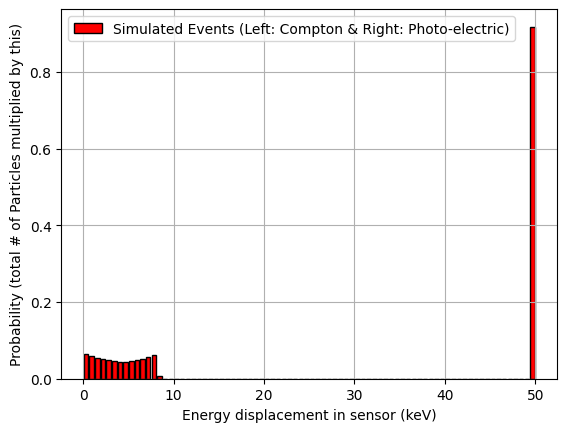

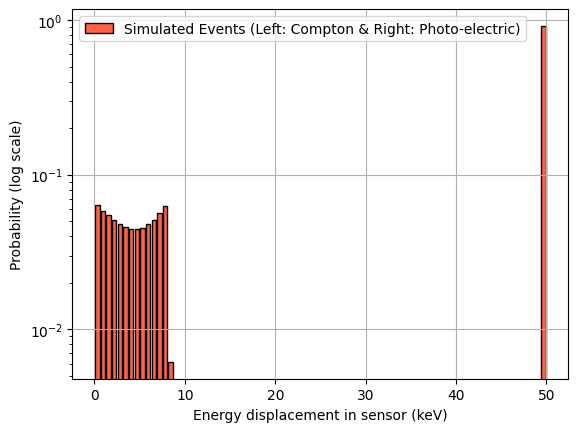

In [15]:
# Plot the whole thing----------------

# plt.xkcd()

plt.hist(compton_and_photo, bins=80, rwidth=0.8, density=True, color='red', edgecolor='black',
         label="Simulated Events (Left: Compton & Right: Photo-electric)")
plt.xlabel("Energy displacement in sensor (keV)")
plt.ylabel("Probability (total # of Particles multiplied by this)")
plt.legend()
plt.grid(True)
plt.show()

# Log scale would be interesting...

plt.hist(compton_and_photo, bins=80, rwidth=0.8, density=True, color='tomato', edgecolor='black',
         label="Simulated Events (Left: Compton & Right: Photo-electric)")
plt.xlabel("Energy displacement in sensor (keV)")
plt.ylabel("Probability (log scale)")
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()